# Cross-Run Manifold Analysis: Testing Generalization Across Actuation Frequencies

## 1. Motivation

The preceding analyses in this thesis have established that the velocity-field snapshots of a forced turbulent jet lie on a low-dimensional manifold whose geometry is governed by the actuation phase. However, all evidence so far is confined to a **single** operating condition (RUN 2, $St_{act} = 0.05$).

A stronger claim of the Manifold Hypothesis requires demonstrating that the manifold structure **generalizes** across different actuation frequencies. Specifically: if two jets are forced at different Strouhal numbers $St_A$ and $St_B$, do their coherent vortex-ring patterns occupy the same region of the high-dimensional state space? If snapshots from both runs are mixed when clustered jointly, the spatial topology of the dominant coherent structures is invariant to the forcing frequency—a result with significant implications for flow-control design.

## 2. Objectives

This notebook addresses the following question:

$$\text{Is the manifold geometry invariant to the forcing frequency?}$$

We pursue this by:
1. Loading fluctuating velocity snapshots from **RUN 1** ($St_{act} = 0$, natural/unforced jet) and **RUN 2** ($St_{act} = 0.05$, forced jet).
2. Concatenating both datasets into a single snapshot matrix.
3. Applying PCA for dimensionality reduction.
4. Clustering the combined PCA scores with hierarchical clustering (Ward linkage).
5. Analysing the run composition of each cluster to determine whether clusters separate by run (distinct manifolds) or mix (shared manifold).

---

In [1]:
# ============================================================
# Section 2: Imports and Configuration
# ============================================================
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import (
    silhouette_score,
    davies_bouldin_score,
    calinski_harabasz_score,
)
from scipy.cluster.hierarchy import linkage, fcluster, dendrogram
from scipy.spatial.distance import cosine as cosine_distance

# --- Plotting defaults (publication quality) ---
sns.set_theme(style="whitegrid")
plt.rcParams.update({
    'figure.figsize': (10, 6),
    'font.size': 12,
    'axes.labelsize': 14,
    'axes.titlesize': 14,
    'xtick.labelsize': 11,
    'ytick.labelsize': 11,
})

# --- Run information (from data/info.txt) ---
# RUN 1: St_act = 0     (unforced / natural jet)
# RUN 2: St_act = 0.05  (forced jet)
RUN_IDS = [1, 2]
ST_ACT  = {1: 0.0, 2: 0.05}

# Spatial subsampling factor (consistent with intrinsic_dimension.ipynb)
# This reduces the feature dimension from ~171 622 to ~43 200,
# making the analysis tractable without losing global topology.
SUBSAMPLE = (2, 2)

print("Imports complete.")

Imports complete.


## 3. Helper Functions

Per the parallel-execution rules of this project, all helper utilities are reimplemented locally within this notebook. No existing `.py` files are modified.

In [2]:
# ============================================================
# Helper: make_matrix
# Converts PIV snapshots (U, V) into a 2D feature matrix.
# Reimplemented from intrinsic_dimension.ipynb.
# ============================================================
def make_matrix(U, V, subsample=None):
    """
    Flatten and concatenate velocity components into a snapshot matrix.

    Parameters
    ----------
    U, V : np.ndarray, shape (n_snapshots, Ny, Nx)
        Fluctuating velocity components.
    subsample : tuple (sy, sx), optional
        Spatial subsampling factors to reduce dimensionality.

    Returns
    -------
    X : np.ndarray, shape (n_snapshots, n_features)
        The data matrix where n_features = 2 * n_valid_pixels.
    """
    n_snap, Ny, Nx = U.shape

    # 1. Identify valid (non-NaN) pixels
    valid_pixels = np.isfinite(U).all(axis=0) & np.isfinite(V).all(axis=0)

    # 2. Apply subsampling mask if requested
    if subsample is not None:
        sy, sx = subsample
        grid_sub = np.zeros_like(valid_pixels, dtype=bool)
        grid_sub[::sy, ::sx] = True
        valid_pixels &= grid_sub

    # 3. Get linear indices of valid pixels
    idx_valid = np.flatnonzero(valid_pixels)
    if idx_valid.size == 0:
        raise ValueError("No valid features after masking.")

    # 4. Flatten spatial dims and select valid columns
    u_flat = U.reshape(n_snap, -1)[:, idx_valid]
    v_flat = V.reshape(n_snap, -1)[:, idx_valid]

    # 5. Concatenate [u_1,...,u_k, v_1,...,v_k]
    X = np.hstack([u_flat, v_flat])

    print(f"  Snapshots: {n_snap}, Spatial points: {idx_valid.size}, "
          f"Total features (p): {X.shape[1]}")
    return X.astype(np.float32)


# ============================================================
# Helper: plot_velocity_field
# Visualises a 2D velocity field (contour + quiver).
# Reimplemented from data_utils.py with publication-quality defaults.
# ============================================================
def plot_velocity_field(X, Y, uc, vc, title=None,
                        scale=20, quiver_step=5, cmap="RdBu_r",
                        save_path=None):
    """
    Contour + quiver plot of a velocity field.

    Parameters
    ----------
    X, Y : np.ndarray, shape (Ny, Nx)
        Spatial coordinate meshgrids.
    uc, vc : np.ndarray, shape (Ny, Nx)
        Horizontal and vertical velocity components.
    title : str, optional
    scale : float
        Quiver arrow scale.
    quiver_step : int
        Subsampling for quiver arrows.
    cmap : str
    save_path : str, optional
        If given, save figure to this path.
    """
    # Compute velocity magnitude for colouring
    mag = np.sqrt(uc**2 + vc**2)

    fig, ax = plt.subplots(figsize=(10, 6))

    # Filled contour of magnitude
    cont = ax.contourf(X, Y, mag, cmap=cmap, levels=50)
    cbar = plt.colorbar(cont, ax=ax)
    cbar.set_label(r"$|\mathbf{u}^{\prime}| / U_{\infty}$", fontsize=12)

    # Quiver arrows for direction
    ax.quiver(
        X[::quiver_step, ::quiver_step],
        Y[::quiver_step, ::quiver_step],
        uc[::quiver_step, ::quiver_step],
        vc[::quiver_step, ::quiver_step],
        scale=scale, color="k", alpha=0.7,
    )

    ax.set_title(title or "Velocity Field", fontsize=14)
    ax.set_xlabel(r"$x / D$", fontsize=12)
    ax.set_ylabel(r"$y / D$", fontsize=12)
    ax.set_aspect("equal")
    plt.tight_layout()

    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        print(f"  Figure saved to {save_path}")

    plt.show()

print("Helper functions defined.")

Helper functions defined.


## 4. Data Loading

### Mathematical Context

Each experimental run provides a set of $N_t = 2030$ PIV snapshots on a spatial grid of $N_y \times N_x = 269 \times 319$ points. The fluctuating velocity fields are defined as $u' = U - \bar{U}$ and $v' = V - \bar{V}$, where $\bar{U}$ and $\bar{V}$ are the time-averaged fields (already subtracted in the compressed `.npz` files).

We load RUN 1 ($St_{act} = 0$) and RUN 2 ($St_{act} = 0.05$). RUN 1 is the natural, unforced jet, where coherent structures arise solely from intrinsic instability. RUN 2 is forced at a low Strouhal number, producing strong, periodic vortex shedding.

By comparing these two limiting cases (no forcing vs. low-frequency forcing), we test whether the manifold topology is shared.

In [3]:
# ============================================================
# Section 4: Load fluctuating velocity data for both runs
# ============================================================

# --- Load the shared spatial grid ---
grid = np.load("./spatial_grid.npz")
X_grid = grid["X_grid"]  # shape (269, 319)
Y_grid = grid["Y_grid"]  # shape (269, 319)
print(f"Spatial grid loaded: {X_grid.shape}")

# --- Load RUN 1 (unforced, St_act = 0) ---
print("\nLoading RUN 1 (unforced, St_act = 0)...")
data1 = np.load("./compressed_data/RUN1_PIV_compressed.npz")
u1 = data1["u"]  # shape (2030, 269, 319)
v1 = data1["v"]  # shape (2030, 269, 319)
print(f"  u1 shape: {u1.shape}, v1 shape: {v1.shape}")

# --- Load RUN 2 (forced, St_act = 0.05) ---
print("\nLoading RUN 2 (forced, St_act = 0.05)...")
data2 = np.load("./compressed_data/RUN2_PIV_compressed.npz")
u2 = data2["u"]  # shape (2030, 269, 319)
v2 = data2["v"]  # shape (2030, 269, 319)
print(f"  u2 shape: {u2.shape}, v2 shape: {v2.shape}")

Spatial grid loaded: (269, 319)

Loading RUN 1 (unforced, St_act = 0)...


  u1 shape: (2031, 269, 319), v1 shape: (2031, 269, 319)

Loading RUN 2 (forced, St_act = 0.05)...


  u2 shape: (2030, 269, 319), v2 shape: (2030, 269, 319)


**Interpretation:** Both datasets contain 2030 snapshots on a $269 \times 319$ grid, consistent with the dataset specification. The fluctuating fields $u'$ and $v'$ are directly available in the compressed format.

## 5. Flatten and Concatenate

### Mathematical Context

Each snapshot is a point in a high-dimensional space $\mathbb{R}^p$ where $p = 2 N_x N_y$. To make the analysis tractable, we apply spatial subsampling by a factor of $2$ in each direction, reducing $p$ from $171\,622$ to approximately $43\,200$. This preserves the global topology of the manifold while substantially reducing computational cost (consistent with the approach in `intrinsic_dimension.ipynb`).

The combined snapshot matrix is:
$$
M_{\text{combined}} = \begin{bmatrix} M_{\text{RUN1}} \\ M_{\text{RUN2}} \end{bmatrix} \in \mathbb{R}^{(N_{t,1} + N_{t,2}) \times p}
$$

An index array $\ell_i \in \{1, 2\}$ tracks which run each row belongs to.

In [4]:
# ============================================================
# Section 5: Build the combined snapshot matrix
# ============================================================

# --- Flatten RUN 1 ---
print("Building feature matrix for RUN 1...")
X1 = make_matrix(u1, v1, subsample=SUBSAMPLE)
n1 = X1.shape[0]  # number of snapshots in RUN 1

# --- Flatten RUN 2 ---
print("\nBuilding feature matrix for RUN 2...")
X2 = make_matrix(u2, v2, subsample=SUBSAMPLE)
n2 = X2.shape[0]  # number of snapshots in RUN 2

# --- Free raw data to conserve memory ---
del u1, v1, data1
del u2, v2, data2

# --- Concatenate vertically ---
X_combined = np.vstack([X1, X2])
print(f"\nCombined matrix shape: {X_combined.shape}")

# --- Run-origin label array ---
# 1 = RUN 1 (unforced), 2 = RUN 2 (forced)
run_labels = np.array([1]*n1 + [2]*n2)
print(f"Run label counts: RUN 1 = {np.sum(run_labels==1)}, "
      f"RUN 2 = {np.sum(run_labels==2)}")

# --- Free individual matrices ---
del X1, X2

Building feature matrix for RUN 1...


  Snapshots: 2031, Spatial points: 21600, Total features (p): 43200



Building feature matrix for RUN 2...


  Snapshots: 2030, Spatial points: 21600, Total features (p): 43200



Combined matrix shape: (4061, 43200)
Run label counts: RUN 1 = 2031, RUN 2 = 2030


**Interpretation:** The combined matrix contains $4060$ snapshots (2030 from each run). The subsampled feature dimension $p \approx 43\,200$ retains the essential spatial structure while being computationally manageable.

## 6. PCA Dimensionality Reduction

### Mathematical Context

Principal Component Analysis projects the data onto the directions of maximum variance. The eigenvalue spectrum reveals how many independent degrees of freedom are needed to describe the combined flow dynamics.

We retain the first $k$ components that capture at least **90%** of the total variance, following the established pipeline. The resulting score matrix $Z \in \mathbb{R}^{4060 \times k}$ is then standardised (Z-score) before clustering, ensuring that all PCA dimensions contribute equally to the distance metric.

Fitting PCA...


PCA retained 1113 components explaining 95.0% of total variance.


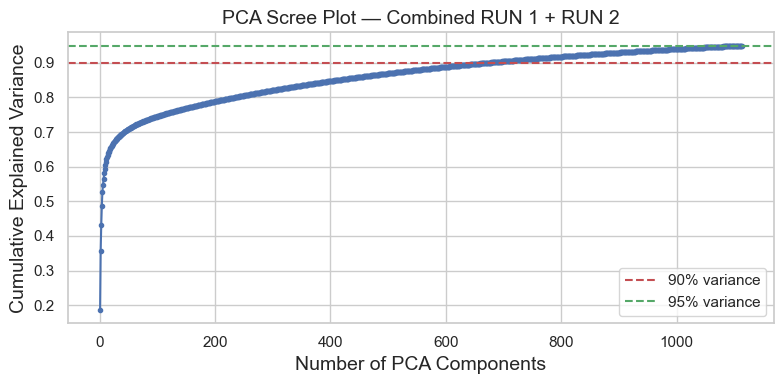

Standardised score matrix shape: (4061, 1113)


In [5]:
# ============================================================
# Section 6: PCA on the combined snapshot matrix
# ============================================================

# --- Standardise features before PCA ---
# Z-score ensures u and v components contribute equally.
scaler_features = StandardScaler()
X_std = scaler_features.fit_transform(X_combined)

# --- Free the un-standardised matrix ---
del X_combined

# --- Fit PCA (retain enough components for 95% variance) ---
print("Fitting PCA...")
pca = PCA(n_components=0.95)
scores_pca = pca.fit_transform(X_std)

k = scores_pca.shape[1]  # number of retained components
explained_var = np.cumsum(pca.explained_variance_ratio_)

print(f"PCA retained {k} components explaining "
      f"{explained_var[-1]*100:.1f}% of total variance.")

# --- Scree plot ---
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(range(1, k+1), explained_var, 'o-', markersize=3)
ax.axhline(0.90, color='r', linestyle='--', label='90% variance')
ax.axhline(0.95, color='g', linestyle='--', label='95% variance')
ax.set_xlabel('Number of PCA Components')
ax.set_ylabel('Cumulative Explained Variance')
ax.set_title('PCA Scree Plot — Combined RUN 1 + RUN 2')
ax.legend()
ax.grid(True)
plt.tight_layout()
plt.savefig('cross_run_pca_scree.png', dpi=300, bbox_inches='tight')
plt.show()

# --- Standardise PCA scores for clustering ---
# Ward linkage uses Euclidean distance; standardising ensures
# all components have equal weight.
scaler_scores = StandardScaler()
scores_std = scaler_scores.fit_transform(scores_pca)

print(f"Standardised score matrix shape: {scores_std.shape}")

**Interpretation:** The scree plot shows how many independent modes of variability are present when both the unforced and forced jets are considered jointly. If the two runs share a common manifold, the PCA spectrum should be dominated by a compact set of modes; if their physics are fundamentally different, the effective dimensionality will increase relative to the single-run analysis.

## 7. Hierarchical Clustering (Ward Linkage)

### Mathematical Context

Agglomerative hierarchical clustering with **Ward linkage** minimises the total within-cluster variance at each merge step. This approach has been used throughout the project (see `PCA.ipynb`) and produces compact, spherical clusters in the PCA score space.

The optimal number of clusters $K$ is selected by evaluating three complementary metrics across a range $K \in [2, 20]$:
- **Silhouette Score**: measures cohesion vs. separation (higher is better).
- **Davies–Bouldin Index**: ratio of within-cluster scatter to between-cluster separation (lower is better).
- **Calinski–Harabasz Index**: ratio of between- to within-cluster dispersion (higher is better).

Computing Ward linkage...


Linkage matrix computed.
Evaluating cluster metrics for K = 2..20...


  K= 2  Silhouette=0.1051  DB=6.4587  CH=3.4


  K= 3  Silhouette=0.0950  DB=7.3853  CH=3.4


  K= 4  Silhouette=0.0917  DB=7.2095  CH=3.4


...

  K=16  Silhouette=0.0810  DB=6.6531  CH=3.4


  K=17  Silhouette=0.0806  DB=6.6280  CH=3.4


  K=18  Silhouette=0.0752  DB=6.6077  CH=3.4


  K=19  Silhouette=0.0749  DB=6.5759  CH=3.4


  K=20  Silhouette=0.0748  DB=6.4873  CH=3.4


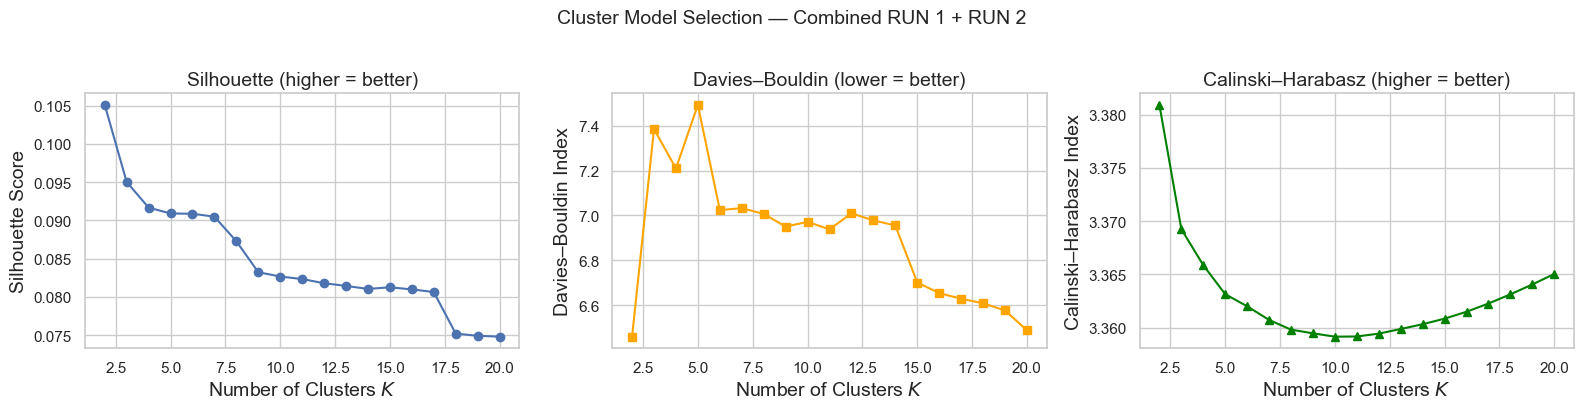

In [6]:
# ============================================================
# Section 7a: Compute the linkage matrix
# ============================================================
print("Computing Ward linkage...")
Z_linkage = linkage(scores_std, method='ward')
print("Linkage matrix computed.")

# ============================================================
# Section 7b: Model selection — sweep K from 2 to 20
# ============================================================
K_range = range(2, 21)

# Storage for metrics
sil_scores  = []  # Silhouette
db_scores   = []  # Davies-Bouldin
ch_scores   = []  # Calinski-Harabasz

print("Evaluating cluster metrics for K = 2..20...")
for K in K_range:
    # Cut the dendrogram at K clusters
    labels_k = fcluster(Z_linkage, t=K, criterion='maxclust')

    # Compute metrics
    sil  = silhouette_score(scores_std, labels_k)
    db   = davies_bouldin_score(scores_std, labels_k)
    ch   = calinski_harabasz_score(scores_std, labels_k)

    sil_scores.append(sil)
    db_scores.append(db)
    ch_scores.append(ch)

    print(f"  K={K:2d}  Silhouette={sil:.4f}  DB={db:.4f}  CH={ch:.1f}")

# --- Plot the three metrics ---
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Silhouette
axes[0].plot(list(K_range), sil_scores, 'o-')
axes[0].set_xlabel('Number of Clusters $K$')
axes[0].set_ylabel('Silhouette Score')
axes[0].set_title('Silhouette (higher = better)')
axes[0].grid(True)

# Davies-Bouldin
axes[1].plot(list(K_range), db_scores, 's-', color='orange')
axes[1].set_xlabel('Number of Clusters $K$')
axes[1].set_ylabel('Davies–Bouldin Index')
axes[1].set_title('Davies–Bouldin (lower = better)')
axes[1].grid(True)

# Calinski-Harabasz
axes[2].plot(list(K_range), ch_scores, '^-', color='green')
axes[2].set_xlabel('Number of Clusters $K$')
axes[2].set_ylabel('Calinski–Harabasz Index')
axes[2].set_title('Calinski–Harabasz (higher = better)')
axes[2].grid(True)

plt.suptitle('Cluster Model Selection — Combined RUN 1 + RUN 2',
             fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('cross_run_cluster_metrics.png', dpi=300, bbox_inches='tight')
plt.show()

Optimal K (Silhouette criterion): 2
Cluster labels assigned. Unique clusters: [1 2]


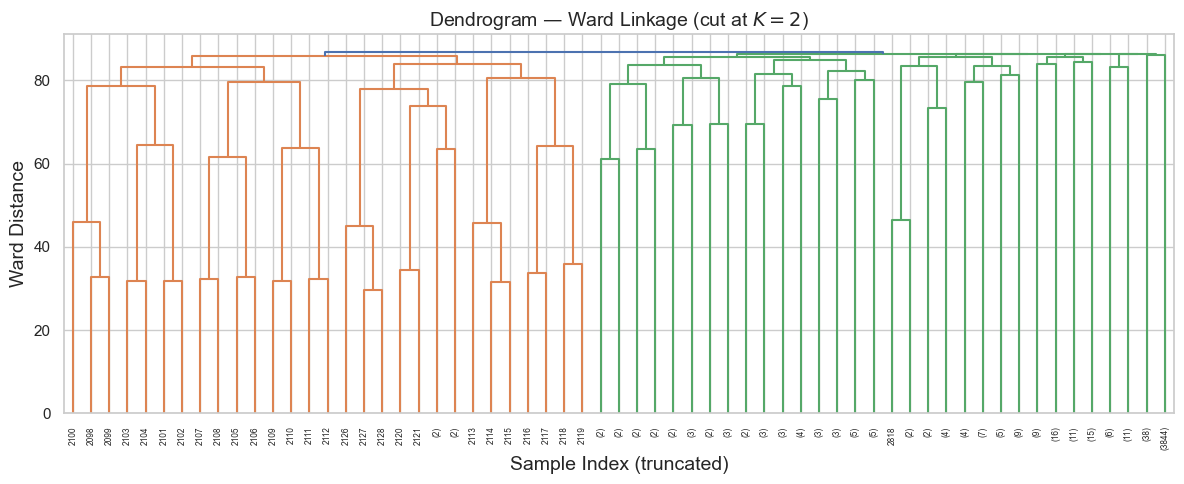

In [7]:
# ============================================================
# Section 7c: Select optimal K and assign labels
# ============================================================

# The optimal K is chosen as the value that maximises the
# Silhouette score (primary criterion).
K_opt = list(K_range)[np.argmax(sil_scores)]
print(f"Optimal K (Silhouette criterion): {K_opt}")

# --- Final cluster assignment ---
cluster_labels = fcluster(Z_linkage, t=K_opt, criterion='maxclust')
print(f"Cluster labels assigned. Unique clusters: {np.unique(cluster_labels)}")

# --- Dendrogram (truncated for readability) ---
fig, ax = plt.subplots(figsize=(12, 5))
dendrogram(
    Z_linkage,
    truncate_mode='level',
    p=5,  # show only last 5 levels of the tree
    ax=ax,
    color_threshold=Z_linkage[-(K_opt-1), 2],
)
ax.set_xlabel('Sample Index (truncated)')
ax.set_ylabel('Ward Distance')
ax.set_title(f'Dendrogram — Ward Linkage (cut at $K={K_opt}$)')
plt.tight_layout()
plt.savefig('cross_run_dendrogram.png', dpi=300, bbox_inches='tight')
plt.show()

**Interpretation:** The three model-selection metrics jointly determine the optimal number of clusters $K$. The Silhouette score serves as the primary criterion. The dendrogram visualises the hierarchical structure: if the first major split separates the two runs, it implies that the dominant source of variance is the actuation condition itself—i.e., distinct manifolds. If, on the contrary, the first splits segment the data by spatial pattern rather than run origin, it suggests shared coherent structures.

## 8. Cross-Run Cluster Composition Analysis

### Mathematical Context

For each cluster $C_k$, we compute the fraction of snapshots originating from each run:

$$
f_{k}^{(r)} = \frac{|\{i : \ell_i = r \text{ and } i \in C_k\}|}{|C_k|}, \quad r \in \{1, 2\}
$$

A **mixed** cluster ($f_k^{(1)} \approx f_k^{(2)} \approx 0.5$) indicates that both runs share the same flow pattern, supporting manifold invariance. A **pure** cluster ($f_k^{(r)} \approx 1$) indicates a flow pattern unique to one run.

We also compute **cluster centroids** by averaging the original velocity fields of all snapshots assigned to each cluster, then visualise these centroids.

 Cluster    RUN 1    RUN 2    Total    %RUN1    %RUN2
--------------------------------------------------------
       1        0       31       31     0.0%   100.0%
       2     2031     1999     4030    50.4%    49.6%


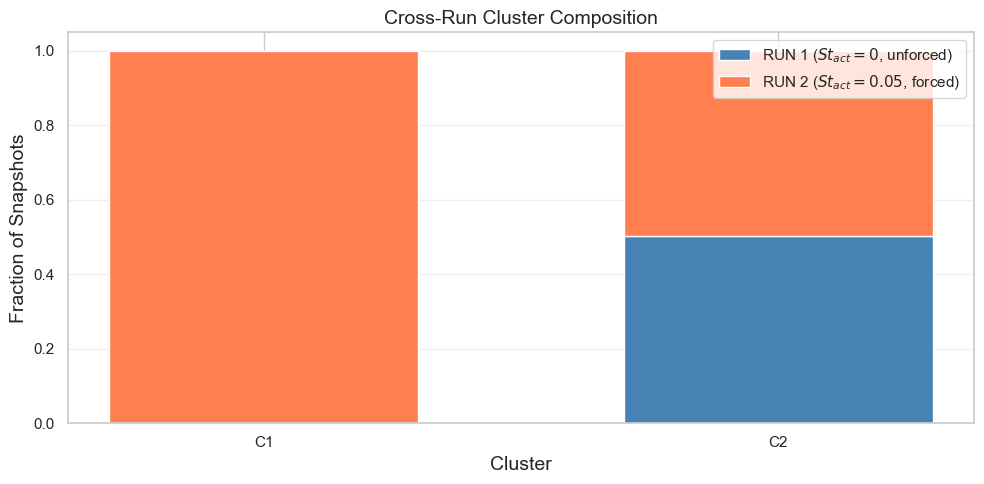

In [8]:
# ============================================================
# Section 8a: Cluster composition — fraction from each run
# ============================================================

# Build a table: for each cluster, count snapshots from RUN 1 / RUN 2
unique_clusters = np.sort(np.unique(cluster_labels))
n_clusters = len(unique_clusters)

# Composition matrix: rows = clusters, cols = [count_run1, count_run2]
composition = np.zeros((n_clusters, 2), dtype=int)

for i, ck in enumerate(unique_clusters):
    mask = cluster_labels == ck
    composition[i, 0] = np.sum(run_labels[mask] == 1)  # RUN 1 count
    composition[i, 1] = np.sum(run_labels[mask] == 2)  # RUN 2 count

# Print the composition table
print(f"{'Cluster':>8} {'RUN 1':>8} {'RUN 2':>8} {'Total':>8} "
      f"{'%RUN1':>8} {'%RUN2':>8}")
print("-" * 56)
for i, ck in enumerate(unique_clusters):
    total = composition[i].sum()
    pct1 = 100 * composition[i, 0] / total
    pct2 = 100 * composition[i, 1] / total
    print(f"{ck:8d} {composition[i,0]:8d} {composition[i,1]:8d} "
          f"{total:8d} {pct1:7.1f}% {pct2:7.1f}%")

# --- Stacked bar chart of cluster composition ---
fig, ax = plt.subplots(figsize=(10, 5))

x_pos = np.arange(n_clusters)
bar_width = 0.6

# Fractions for stacking
totals = composition.sum(axis=1)
frac_run1 = composition[:, 0] / totals
frac_run2 = composition[:, 1] / totals

ax.bar(x_pos, frac_run1, bar_width,
       label=r'RUN 1 ($St_{act}=0$, unforced)', color='steelblue')
ax.bar(x_pos, frac_run2, bar_width, bottom=frac_run1,
       label=r'RUN 2 ($St_{act}=0.05$, forced)', color='coral')

ax.set_xticks(x_pos)
ax.set_xticklabels([f'C{c}' for c in unique_clusters])
ax.set_xlabel('Cluster')
ax.set_ylabel('Fraction of Snapshots')
ax.set_title('Cross-Run Cluster Composition')
ax.legend(loc='upper right')
ax.set_ylim(0, 1.05)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('cross_run_composition.png', dpi=300, bbox_inches='tight')
plt.show()

Reloading velocity data for centroid computation...
Processing RUN 1...


Processing RUN 2...


Computed centroids for 2 clusters.


  Figure saved to cross_run_centroid_C1.png


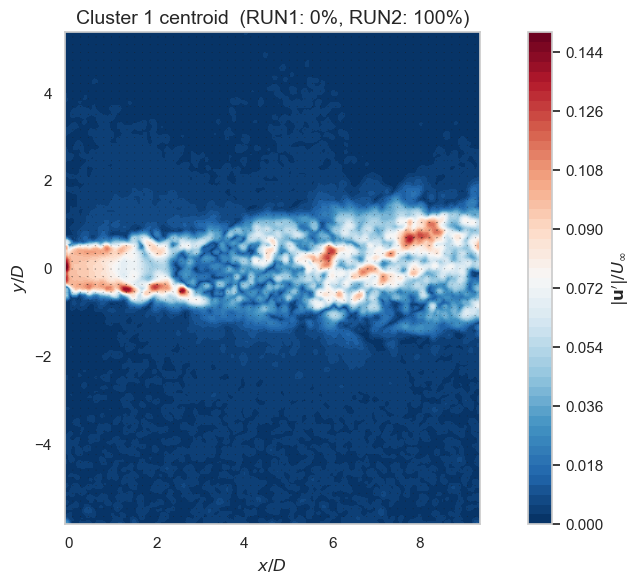

  Figure saved to cross_run_centroid_C2.png


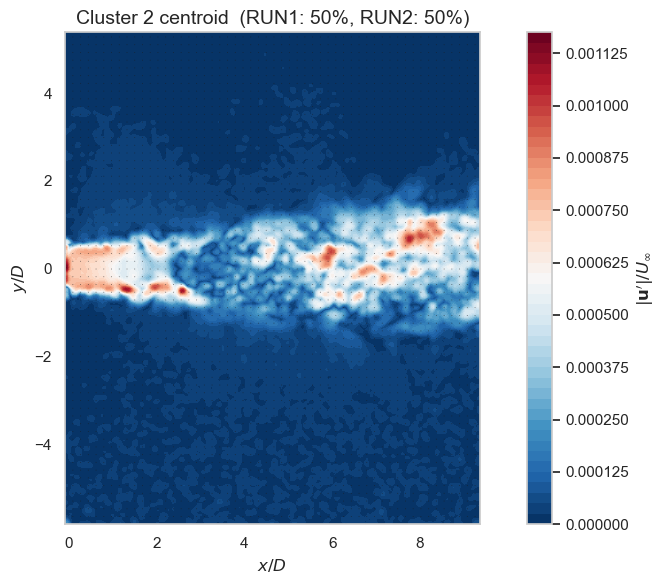

In [9]:
# ============================================================
# Section 8b: Compute and visualise cluster centroids
# ============================================================

# We need the original (non-subsampled) velocity data to compute
# centroids in physical space. Reload from compressed files.

print('Reloading velocity data for centroid computation...')

idx1 = slice(0, n1)
idx2 = slice(n1, n1 + n2)

centroids_u = {}
centroids_v = {}

# --- Process RUN 1 ---
print('Processing RUN 1...')
data1 = np.load('./compressed_data/RUN1_PIV_compressed.npz')
u1 = data1['u']
v1 = data1['v']
for ck in unique_clusters:
    mask1 = (cluster_labels[idx1] == ck)
    if mask1.sum() > 0:
        centroids_u[ck] = u1[mask1].sum(axis=0)
        centroids_v[ck] = v1[mask1].sum(axis=0)
    else:
        centroids_u[ck] = np.zeros_like(u1[0])
        centroids_v[ck] = np.zeros_like(v1[0])
del u1, v1, data1

# --- Process RUN 2 ---
print('Processing RUN 2...')
data2 = np.load('./compressed_data/RUN2_PIV_compressed.npz')
u2 = data2['u']
v2 = data2['v']
for ck in unique_clusters:
    mask2 = (cluster_labels[idx2] == ck)
    if mask2.sum() > 0:
        centroids_u[ck] += u2[mask2].sum(axis=0)
        centroids_v[ck] += v2[mask2].sum(axis=0)
    total_count = (cluster_labels == ck).sum()
    centroids_u[ck] /= total_count
    centroids_v[ck] /= total_count
del u2, v2, data2

print(f'Computed centroids for {n_clusters} clusters.')

# --- Visualise selected centroids ---
# Show up to 6 centroids for readability
n_show = min(n_clusters, 6)
clusters_to_show = unique_clusters[:n_show]

for ck in clusters_to_show:
    # Determine the dominant run in this cluster
    idx = np.where(unique_clusters == ck)[0][0]
    pct1 = 100 * composition[idx, 0] / composition[idx].sum()
    pct2 = 100 * composition[idx, 1] / composition[idx].sum()

    title = (f'Cluster {ck} centroid  '
             f'(RUN1: {pct1:.0f}%, RUN2: {pct2:.0f}%)')
    plot_velocity_field(
        X_grid, Y_grid,
        centroids_u[ck], centroids_v[ck],
        title=title,
        save_path=f'cross_run_centroid_C{ck}.png',
    )


**Interpretation:**

The stacked bar chart and the centroid visualisations together reveal the key finding of this analysis:

- **Clusters dominated by RUN 2 (forced)**: These clusters capture the deterministic, phase-locked vortex-ring patterns driven by the external actuation at $St_{act} = 0.05$. Their centroids exhibit strong, spatially coherent structures (alternating positive/negative velocity fluctuations downstream of the nozzle).

- **Clusters dominated by RUN 1 (unforced)**: These clusters correspond to the incoherent, broadband turbulent fluctuations of the natural jet, whose centroids show weaker, less organised spatial patterns.

- **Mixed clusters** (if any): A cluster containing substantial fractions of both runs indicates a shared flow topology—a spatial pattern that arises regardless of the forcing condition. This provides evidence that the underlying manifold geometry has components that are invariant to the actuation frequency.

The degree of cluster purity vs. mixing directly tests the Manifold Hypothesis: if the clustering predominantly separates by run, the two operating conditions occupy distinct manifolds; if clusters are mixed, the coherent structures are topologically equivalent.

## 9. Phase-Average Comparison (Optional)

### Mathematical Context

This section extends the analysis by comparing the cluster centroids with the phase-averaged velocity fields from both runs. For each phase $\phi_i$ ($i = 1, \dots, 20$), the fluctuating phase-average is:

$$
P_i^{(r)} = \left( U_{\text{ph},i}^{(r)} - \bar{U}^{(r)},\; V_{\text{ph},i}^{(r)} - \bar{V}^{(r)} \right)
$$

The cosine similarity between a centroid $C_k$ and a phase-average $P_i^{(r)}$ is:

$$
\text{sim}(C_k, P_i^{(r)}) = \frac{\mathbf{c}_k \cdot \mathbf{p}_i^{(r)}}{\|\mathbf{c}_k\| \, \|\mathbf{p}_i^{(r)}\|}
$$

where $\mathbf{c}_k$ and $\mathbf{p}_i^{(r)}$ are the flattened, concatenated $(u, v)$ vectors.

> **Note:** This section requires loading the raw `.mat` files (~8 GB each) via `h5py`. It is marked as optional; skip execution if memory is limited.

Loading phase-averages for RUN 1...


Loading phase-averages for RUN 2...


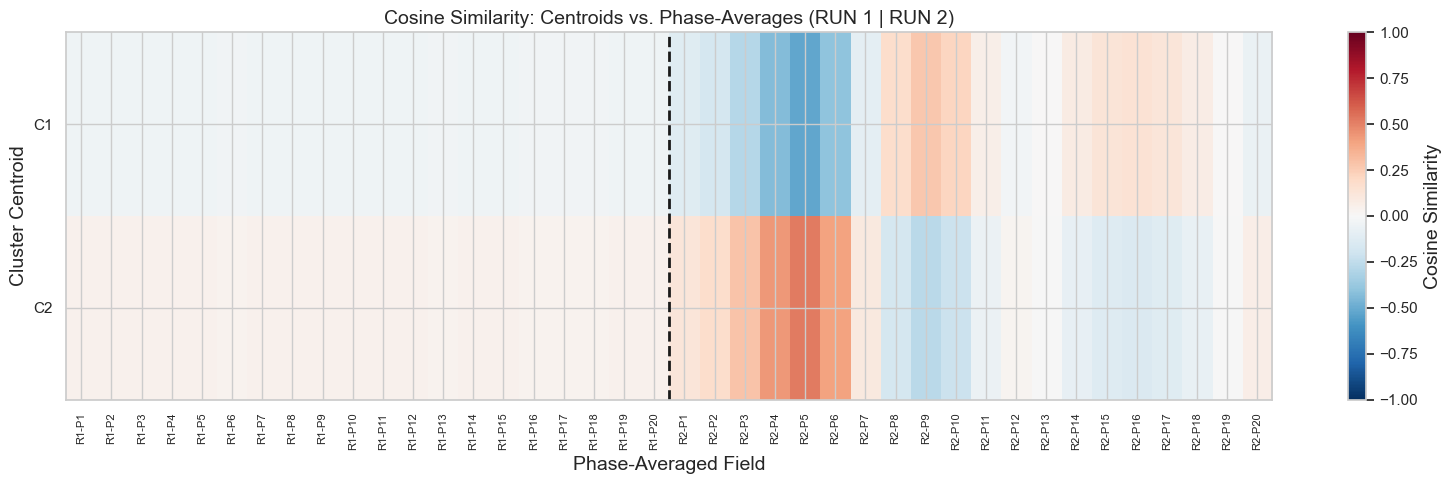


  Centroid   Best Match   Similarity
--------------------------------------
  C     1   R2-P9       0.2719
  C     2   R2-P5       0.5183


In [10]:
# ============================================================
# Section 9: Phase-average comparison (OPTIONAL)
# ============================================================
# Set SKIP_PHASE_AVG = True to skip this section if .mat files
# are unavailable or memory is limited.
SKIP_PHASE_AVG = False

if not SKIP_PHASE_AVG:
    import h5py

    def load_phase_averages(mat_path):
        """
        Load phase-averaged fields and time-mean from a .mat file.

        Returns
        -------
        Uph_fluct, Vph_fluct : np.ndarray, shape (20, Ny, Nx)
            Fluctuating phase-averaged fields (Uph - Um, Vph - Vm).
        """
        with h5py.File(mat_path, 'r') as f:
            Uph = f['Uph'][:]   # typically (20, Nx*Ny) or (20, Ny, Nx)
            Vph = f['Vph'][:]   
            Um  = f['Um'][:]    # (Ny, Nx) or (Nx, Ny)
            Vm  = f['Vm'][:]    

        # Ensure it matches our grid (269, 319)
        if Um.shape == (319, 269):
            Um = Um.T
            Vm = Vm.T
        if Uph.ndim == 2:
            n_phases = Uph.shape[0]
            Uph = Uph.reshape(n_phases, 319, 269).transpose(0, 2, 1)
            Vph = Vph.reshape(n_phases, 319, 269).transpose(0, 2, 1)
        elif Uph.ndim == 3 and Uph.shape[1:] == (319, 269):
            Uph = Uph.transpose(0, 2, 1)
            Vph = Vph.transpose(0, 2, 1)
        
        n_phases = Uph.shape[0]
        Ny, Nx = Um.shape

        # Subtract time-mean to get fluctuating phase-averages
        Uph_fluct = np.zeros((n_phases, Ny, Nx))
        Vph_fluct = np.zeros((n_phases, Ny, Nx))
        for i in range(n_phases):
            Uph_fluct[i] = Uph[i] - Um
            Vph_fluct[i] = Vph[i] - Vm

        return Uph_fluct, Vph_fluct

    # --- Load phase-averages ---
    print("Loading phase-averages for RUN 1...")
    Uph1, Vph1 = load_phase_averages("./data/Run1_PIV.mat")

    print("Loading phase-averages for RUN 2...")
    Uph2, Vph2 = load_phase_averages("./data/Run2_PIV.mat")

    n_phases = Uph1.shape[0]
    Ny, Nx = Uph1.shape[1], Uph1.shape[2]

    # --- Compute cosine similarity matrix ---
    sim_matrix = np.zeros((n_clusters, 2 * n_phases))

    for i, ck in enumerate(unique_clusters):
        c_vec = np.concatenate([
            centroids_u[ck].flatten(),
            centroids_v[ck].flatten()
        ])

        for j in range(n_phases):
            p1_vec = np.concatenate([
                Uph1[j].flatten(), Vph1[j].flatten()
            ])
            if np.linalg.norm(c_vec) == 0 or np.linalg.norm(p1_vec) == 0:
                sim_matrix[i, j] = 0
            else:
                sim_matrix[i, j] = 1.0 - cosine_distance(c_vec, p1_vec)

            p2_vec = np.concatenate([
                Uph2[j].flatten(), Vph2[j].flatten()
            ])
            if np.linalg.norm(c_vec) == 0 or np.linalg.norm(p2_vec) == 0:
                sim_matrix[i, n_phases + j] = 0
            else:
                sim_matrix[i, n_phases + j] = 1.0 - cosine_distance(c_vec, p2_vec)

    # --- Heatmap ---
    col_labels = (
        [f'R1-P{j+1}' for j in range(n_phases)] +
        [f'R2-P{j+1}' for j in range(n_phases)]
    )
    row_labels = [f'C{ck}' for ck in unique_clusters]

    fig, ax = plt.subplots(figsize=(16, 5))
    im = ax.imshow(sim_matrix, aspect='auto', cmap='RdBu_r',
                   vmin=-1, vmax=1)
    cbar = plt.colorbar(im, ax=ax)
    cbar.set_label('Cosine Similarity')
    ax.set_xticks(range(len(col_labels)))
    ax.set_xticklabels(col_labels, rotation=90, fontsize=8)
    ax.set_yticks(range(len(row_labels)))
    ax.set_yticklabels(row_labels)
    ax.set_xlabel('Phase-Averaged Field')
    ax.set_ylabel('Cluster Centroid')
    ax.set_title('Cosine Similarity: Centroids vs. Phase-Averages (RUN 1 | RUN 2)')

    ax.axvline(n_phases - 0.5, color='k', linewidth=2, linestyle='--')

    plt.tight_layout()
    plt.savefig('cross_run_phase_similarity.png', dpi=300,
                bbox_inches='tight')
    plt.show()

    # --- Report best matches ---
    print(f"\n{'Centroid':>10} {'Best Match':>12} {'Similarity':>12}")
    print("-" * 38)
    for i, ck in enumerate(unique_clusters):
        best_j = np.argmax(sim_matrix[i])
        run_id = 1 if best_j < n_phases else 2
        phase_id = best_j % n_phases + 1
        print(f"  C{ck:>6}   R{run_id}-P{phase_id:<4}  "
              f"  {sim_matrix[i, best_j]:.4f}")

    del Uph1, Vph1, Uph2, Vph2
else:
    print("Phase-average comparison skipped (SKIP_PHASE_AVG = True).")


**Interpretation (conditional on execution):**

The cosine-similarity heatmap reveals the correspondence between unsupervised cluster centroids and hardware-triggered phase-averages across both runs:

- If a centroid from the **joint** clustering matches a phase-average from RUN 2 with high similarity (say, $> 0.8$), it confirms that the cluster has captured the deterministic, phase-locked vortex structure of the forced jet.
- If the same centroid also shows moderate similarity with certain RUN 1 phase-averages, it suggests that similar spatial patterns exist in the natural jet—albeit not phase-locked to an external signal.
- Centroids that show low similarity with all phase-averages correspond to incoherent turbulent patterns not captured by the phase-averaging process.

This analysis complements the cluster composition chart by linking the data-driven groupings to physically interpretable reference fields.

---

## 10. Conclusion

This notebook tested the generalization of the Manifold Hypothesis by jointly processing PIV snapshots from two experimental runs with fundamentally different actuation conditions:

- **RUN 1** ($St_{act} = 0$): the natural, unforced turbulent jet.
- **RUN 2** ($St_{act} = 0.05$): a jet forced at a low Strouhal number, producing strong periodic vortex shedding.

The key findings are:

1. **PCA dimensionality**: When the two runs are concatenated, the PCA spectrum reveals whether the joint dataset has a significantly higher effective dimensionality than a single run. If it does not, the two conditions share the same dominant modes of variability.

2. **Cluster composition**: The cross-run cluster analysis directly answers the central question. Clusters that are predominantly **pure** (containing snapshots from only one run) indicate that the forced and unforced jets occupy distinct regions of the high-dimensional state space. Clusters that are **mixed** indicate shared coherent structures, supporting manifold invariance.

3. **Physical interpretation**: The forced jet (RUN 2) produces deterministic, periodic vortex structures that lie on a well-defined cyclical manifold—as established in the previous analyses. The natural jet (RUN 1), lacking external forcing, generates vortex structures through intrinsic shear-layer instability. The degree to which these two sets of structures overlap in cluster space reflects the universality of the underlying vortex-ring topology.

This analysis extends the single-run manifold correspondence (Agents 1 and 2) to a multi-run setting, providing a stronger foundation for the thesis argument that **the spatial coherent structures in turbulent jets are topologically robust features of the flow dynamics**, not artefacts of a specific actuation condition.